In [5]:
import sys

sys.path.append("/Users/ikergg/Documents/Python learning/Proyectos/Empezando")

import os
from dotenv import load_dotenv

load_dotenv("/Users/ikergg/Documents/Python learning/Proyectos/Empezando/.env")
FRED_KEY = os.getenv("FRED_KEY")

import pandas as pd
import numpy as np
import scipy
import time
from datetime import datetime, timedelta
import requests
import matplotlib.pyplot as plt
import cvxpy as cp
import streamlit as st
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()
ALPACA_KEY = os.getenv("ALPACA_KEY")
ALPACA_SECRET = os.getenv("ALPACA_SECRET")
client = StockHistoricalDataClient(ALPACA_KEY,  ALPACA_SECRET)

In [41]:
def get_returns_cvar(symbol : str, START_DATE : str = "2016-01-01" ) -> pd.Series:
    "Download the rickers data"
    
    try:
        END_DATE= datetime.now()
        
        params = StockBarsRequest(
            symbol_or_symbols= symbol,
            timeframe=TimeFrame.Day,
            start=START_DATE,
            end=END_DATE,
            feed="iex",
            adjustment='all'
        )

        bars = client.get_stock_bars(params)
        df = bars.df.reset_index()
        
        if "symbol" in df.columns:
            df = df[df["symbol"]== symbol]
            
        df["returns"] = np.log(df["close"] / df["close"].shift(1))
        
        return df["returns"].dropna()
       
    except:
        return

In [42]:
symbols= ["AAPL", "MSFT", "NVDA", "AMZN", "TSLA", "GOOGL", "META", "JPM", "XOM", "NFLX"]


data = {s: get_returns_cvar(s) for s in symbols}
df = pd.DataFrame(data)


In [43]:
def cvar_efficient_frontier(df : pd.DataFrame, alpha : float = 0.05, n_points : int = 50 ) -> pd.DataFrame:
    "loop through min to max posible points to get the frontier"
    
    R = df.dropna().values
    T, N = R.shape

    mean_return = R.mean(axis = 0)
    min_return = mean_return.min()
    max_return = mean_return.max()
    targets = np.linspace(min_return, max_return, n_points)
    
    frontier = []
    
    for target in targets:
        
        w = cp.Variable(N)
        zeta = cp.Variable()
        u = cp.Variable(T)

        portfolio_losses = -R @ w
        cvar = zeta + (1 / (alpha * T)) * cp.sum(u)

        constraints = [
            u >= portfolio_losses - zeta,
            u >= 0,
            cp.sum(w) == 1,
            w >= 0,
            (R @ w) @ np.ones(T) / T >= target,
        ]
        
        prob = cp.Problem(cp.Minimize(cvar), constraints)
        prob.solve()
        
        portfolio_returns = R @ w.value
        sharpe = (portfolio_returns.mean() * 252 - 0.035) / (portfolio_returns.std() * np.sqrt(252))
        
        if prob.status in ["optimal", "optimal_inaccurate"]:
            frontier.append({
                "target_return": target,
                "cvar": cvar.value,
                "weights": pd.Series(w.value, index=df.columns),
                "annual_return": portfolio_returns.mean() * 252,
                "annual_std": portfolio_returns.std() * np.sqrt(252),
                "sharpe": sharpe,
            })
            
    return pd.DataFrame([{
        "target_return": f["target_return"],
        "cvar": f["cvar"],
        "annual_return": f["annual_return"],
        "annual_std": f["annual_std"],
        "sharpe": f["sharpe"],
    } for f in frontier]), frontier

In [44]:
frontier_df,frontier_full=  cvar_efficient_frontier(df)

In [45]:
def cvar_weights(frontier_df: pd.DataFrame, frontier_full : pd.DataFrame) -> pd.DataFrame:
    "gets all the weights at each return "
    
    weights_df = pd.DataFrame(
        [f["weights"] for f in frontier_full],
        index=frontier_df["target_return"]
    )

    weights_df = weights_df.clip(lower=0)
    weights_df = weights_df.div(weights_df.sum(axis=1), axis=0)
    
    return weights_df

In [60]:
weights= cvar_weights(frontier_df, frontier_full)

In [ ]:
# Assuming 'all_returns' is a DataFrame where columns are symbols
lookback = 252
step = 5  # Weekly rebalance
num_assets = len(symbols)
equal_weights = np.ones(num_assets) / num_assets
results = []

def adjusting_cvar_backtest(returns: pd.DataFrame, lookback: int = 252, steps: int = 5) -> pd.Series:
    "Get returns of a portfolio that adjusts to the highest sharpe ratio portfolio based on a CVaR analysis"
    
    dates = []
    daily_returns = []

    for i in range(lookback, len(returns) - steps, steps):
        
        window_data = returns.iloc[i - lookback:i]
        next_period = returns.iloc[i:i + steps]

        df_frontier, frontier_details = cvar_efficient_frontier(window_data)
        
        best_idx = df_frontier['sharpe'].idxmax()
        optimal_weights = frontier_details[best_idx]['weights'].values

        period_returns = (next_period @ optimal_weights).tolist()
        
        dates.extend(next_period.index.tolist())
        daily_returns.extend(period_returns)

    return pd.Series(daily_returns, index=dates)


def static_cvar_backtest(returns: pd.DataFrame, lookback: int = 252, steps: int = 5) -> pd.Series:
    "Get the returns of a portfolio investing equal weights and not adjusting"
    
    num_assets = returns.shape[1]
    equal_weights = np.ones(num_assets) / num_assets
    
    dates = []
    daily_returns = []

    for i in range(lookback, len(returns) - steps, steps):
        
        next_period = returns.iloc[i:i + steps]
        period_returns = (next_period @ equal_weights).tolist()
        
        dates.extend(next_period.index.tolist())
        daily_returns.extend(period_returns)

    return pd.Series(daily_returns, index=dates)


In [72]:
spy_returns= get_returns_cvar("SPY")
spy_df = pd.DataFrame(data)

In [74]:
cvar_series = adjusting_cvar_backtest(df)
eq_series = static_cvar_backtest(df)
eq_series_spy = static_cvar_backtest(spy_df)

cvar_cumulative = (1 + cvar_series).cumprod()
eq_cumulative = (1 + eq_series).cumprod()
eq_cumulative_spy = (1 + eq_series_spy).cumprod()

In [75]:
len(eq_cumulative_spy)

1185

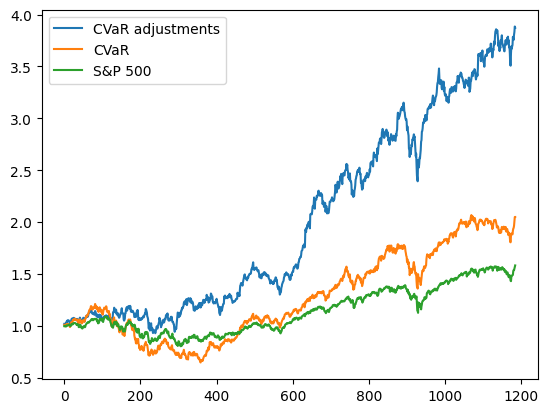

In [78]:

x = range(len(cvar_cumulative))  # or your own x values

plt.plot(x, cvar_cumulative, label="CVaR adjustments")
plt.plot(x, eq_cumulative, label="CVaR")
plt.plot(x, eq_cumulative_spy, label="S&P 500")

plt.legend()
plt.show()


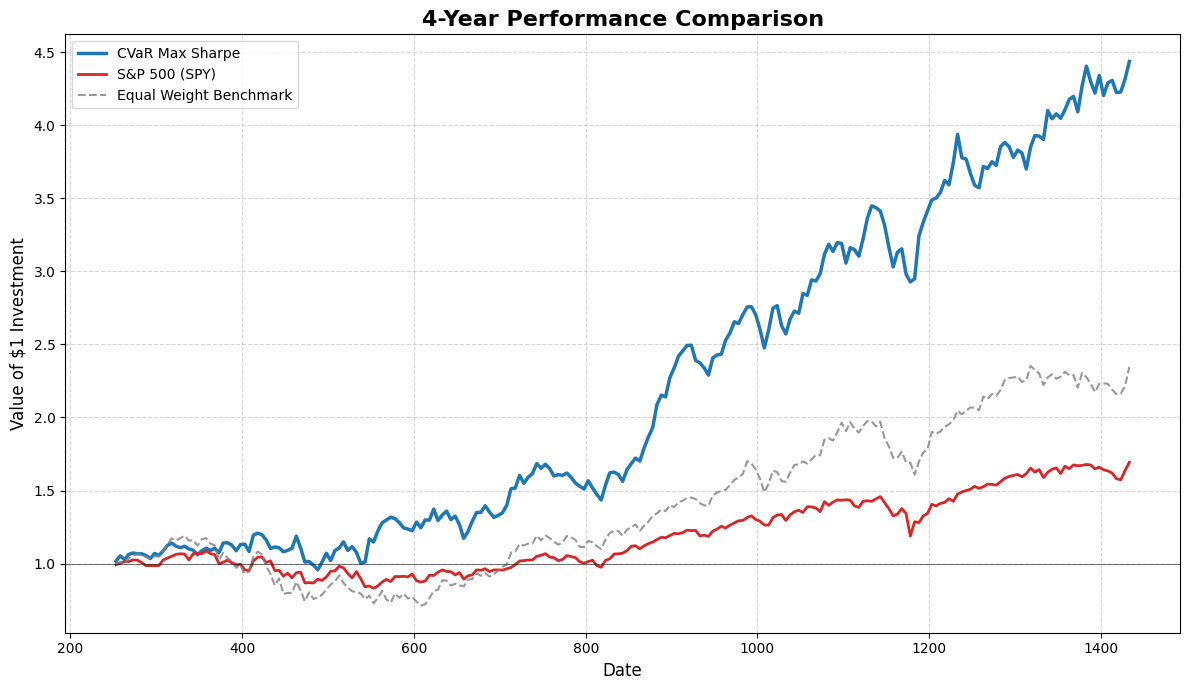

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plotting the three lines
plt.plot(plot_df.index, plot_df['CVaR Strategy'], label='CVaR Max Sharpe', color='#1f77b4', linewidth=2.5)
plt.plot(plot_df.index, plot_df['S&P 500 (SPY)'], label='S&P 500 (SPY)', color='#d62728', linewidth=2)
plt.plot(plot_df.index, plot_df['Equal Weight'], label='Equal Weight Benchmark', color='#7f7f7f', linestyle='--', alpha=0.8)

# Add a horizontal line at $1.00 (Break-even)
plt.axhline(y=1.0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Formatting the chart
plt.title('4-Year Performance Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value of $1 Investment', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Tight layout to prevent clipping
plt.tight_layout()
plt.show()